In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt



In [2]:
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

In [3]:
df = pd.read_csv("results.csv")
df.head()

,Sorting Algorithm,Array Size,Generation Mode,Number of Runs,Average Time,Minimum Time,Maximum Time,Number of Comparisons,Number of Interchanges
0,Merge Sort,10,RANDOM,10,10490.0,7400.0,24000.0,24,34
1,Bubble Sort,10,RANDOM,10,3530.0,3000.0,5500.0,44,23
2,Insertion Sort,10,RANDOM,10,1640.0,1400.0,2800.0,30,23
3,Selection Sort,10,RANDOM,10,2370.0,1800.0,4400.0,45,10
4,Heap Sort,10,RANDOM,10,6900.0,4300.0,18200.0,65,25


In [4]:
df.columns = ['algorithm', 'size', 'mode', 'runs', 'avg_time', 'min_time', 'max_time', 'comparisons', 'interchanges']
df.head()

,algorithm,size,mode,runs,avg_time,min_time,max_time,comparisons,interchanges
0,Merge Sort,10,RANDOM,10,10490.0,7400.0,24000.0,24,34
1,Bubble Sort,10,RANDOM,10,3530.0,3000.0,5500.0,44,23
2,Insertion Sort,10,RANDOM,10,1640.0,1400.0,2800.0,30,23
3,Selection Sort,10,RANDOM,10,2370.0,1800.0,4400.0,45,10
4,Heap Sort,10,RANDOM,10,6900.0,4300.0,18200.0,65,25


In [ ]:
sample = df.sample(20).sort_values('algorithm')
print(sample.to_latex(index=False))

\begin{tabular}{lrlrrrrrr}
\toprule
algorithm & size & mode & runs & avg_time & min_time & max_time & comparisons & interchanges \\
\midrule
Bubble Sort & 1000 & INVERSELY_SORTED & 10 & 710260.000000 & 693500.000000 & 734200.000000 & 499500 & 499496 \\
Bubble Sort & 10000 & INVERSELY_SORTED & 10 & 88344930.000000 & 83231200.000000 & 99570200.000000 & 49995000 & 49994524 \\
Heap Sort & 5000 & RANDOM & 10 & 507000.000000 & 482400.000000 & 525800.000000 & 167215 & 57044 \\
Heap Sort & 2500 & NEARLY_SORTED & 10 & 238090.000000 & 218800.000000 & 268400.000000 & 76066 & 26009 \\
Insertion Sort & 10000 & RANDOM & 10 & 21546330.000000 & 16784200.000000 & 32005300.000000 & 24846727 & 24836739 \\
Merge Sort & 50 & RANDOM & 10 & 10970.000000 & 8900.000000 & 17100.000000 & 224 & 286 \\
Merge Sort & 500 & INVERSELY_SORTED & 10 & 3459120.000000 & 48200.000000 & 34066700.000000 & 2216 & 4488 \\
Quick Sort & 10 & NEARLY_SORTED & 10 & 22630.000000 & 700.000000 & 175900.000000 & 28 & 19 \\
Selection Sor

In [6]:
for column in ["avg_time", "min_time", "max_time"]:
    df[column] = df[column] / 1e6
df.head()

,algorithm,size,mode,runs,avg_time,min_time,max_time,comparisons,interchanges
0,Merge Sort,10,RANDOM,10,0.01049,0.0074,0.0240,24,34
1,Bubble Sort,10,RANDOM,10,0.00353,0.0030,0.0055,44,23
2,Insertion Sort,10,RANDOM,10,0.00164,0.0014,0.0028,30,23
3,Selection Sort,10,RANDOM,10,0.00237,0.0018,0.0044,45,10
4,Heap Sort,10,RANDOM,10,0.00690,0.0043,0.0182,65,25


In [7]:
print(df.shape)
print(df['algorithm'].unique())
print(df['mode'].unique())
print(df['size'].unique())

(2160, 9)
['Merge Sort' 'Bubble Sort' 'Insertion Sort' 'Selection Sort' 'Heap Sort'
 'Quick Sort']
['RANDOM' 'SORTED' 'INVERSELY_SORTED' 'NEARLY_SORTED']
[   10    50   100   250   500  1000  2500  5000 10000]


In [11]:
agg = df.groupby(["algorithm", "size", "mode"]).agg(
    avg_time=("avg_time", "median"),
    min_time=("min_time", "min"),
    max_time=("max_time", "max"),
    comparisons=("comparisons", "median"),
    interchanges=("interchanges", "median")
).reset_index()
print(agg.shape)
agg.head()

(216, 8)


,algorithm,size,mode,avg_time,min_time,max_time,comparisons,interchanges
0,Bubble Sort,10,INVERSELY_SORTED,0.003465,0.0003,0.0259,45.0,45.0
1,Bubble Sort,10,NEARLY_SORTED,0.002400,0.0003,0.0141,42.0,20.0
2,Bubble Sort,10,RANDOM,0.003290,0.0003,0.0170,44.0,23.5
3,Bubble Sort,10,SORTED,0.000580,0.0001,0.0042,9.0,0.0
4,Bubble Sort,50,INVERSELY_SORTED,0.012520,0.0083,13.0109,1225.0,1225.0


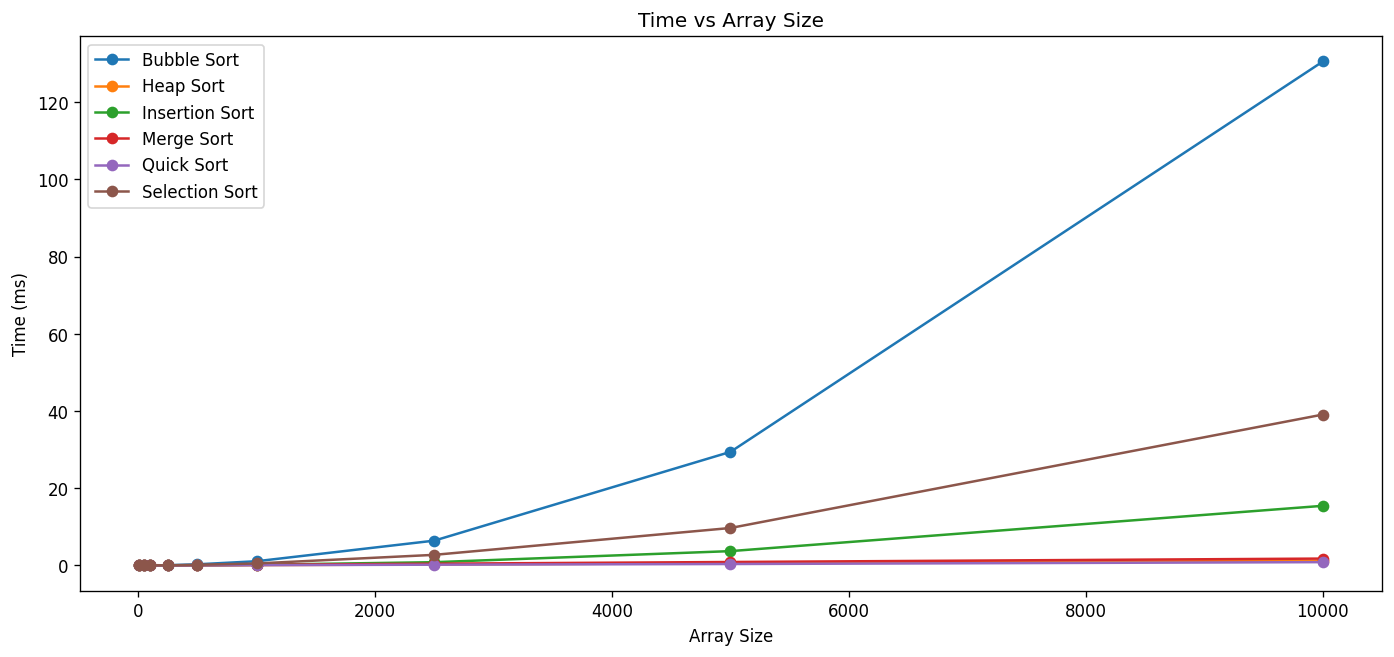

In [12]:
scaling = agg.groupby(['algorithm', 'size'])['avg_time'].median().reset_index()

for algo in scaling['algorithm'].unique():
    subset = scaling[scaling['algorithm'] == algo]
    plt.plot(subset['size'], subset['avg_time'], marker='o', label=algo)

plt.title('Time vs Array Size')
plt.xlabel('Array Size')
plt.ylabel('Time (ms)')
plt.legend()
plt.show()

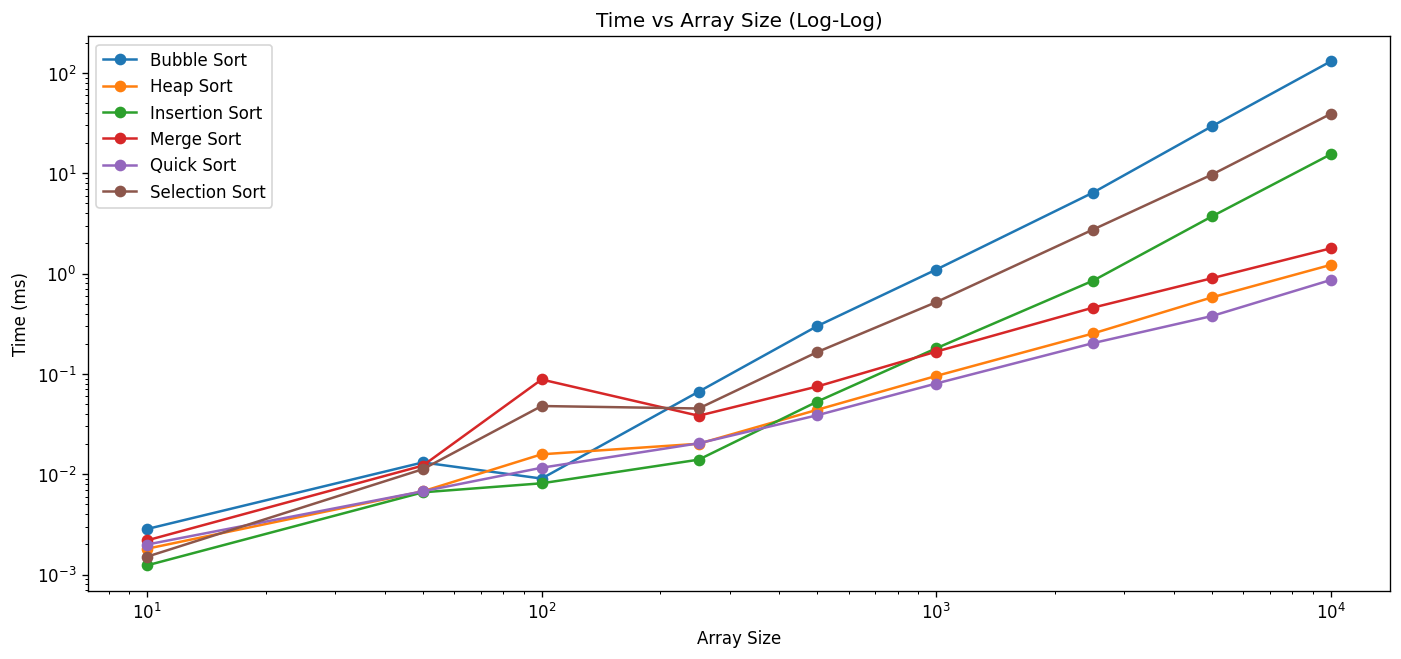

In [13]:
for algo in scaling['algorithm'].unique():
    subset = scaling[scaling['algorithm'] == algo]
    plt.loglog(subset['size'], subset['avg_time'], marker='o', label=algo)

plt.title('Time vs Array Size (Log-Log)')
plt.xlabel('Array Size')
plt.ylabel('Time (ms)')
plt.legend()
plt.show()

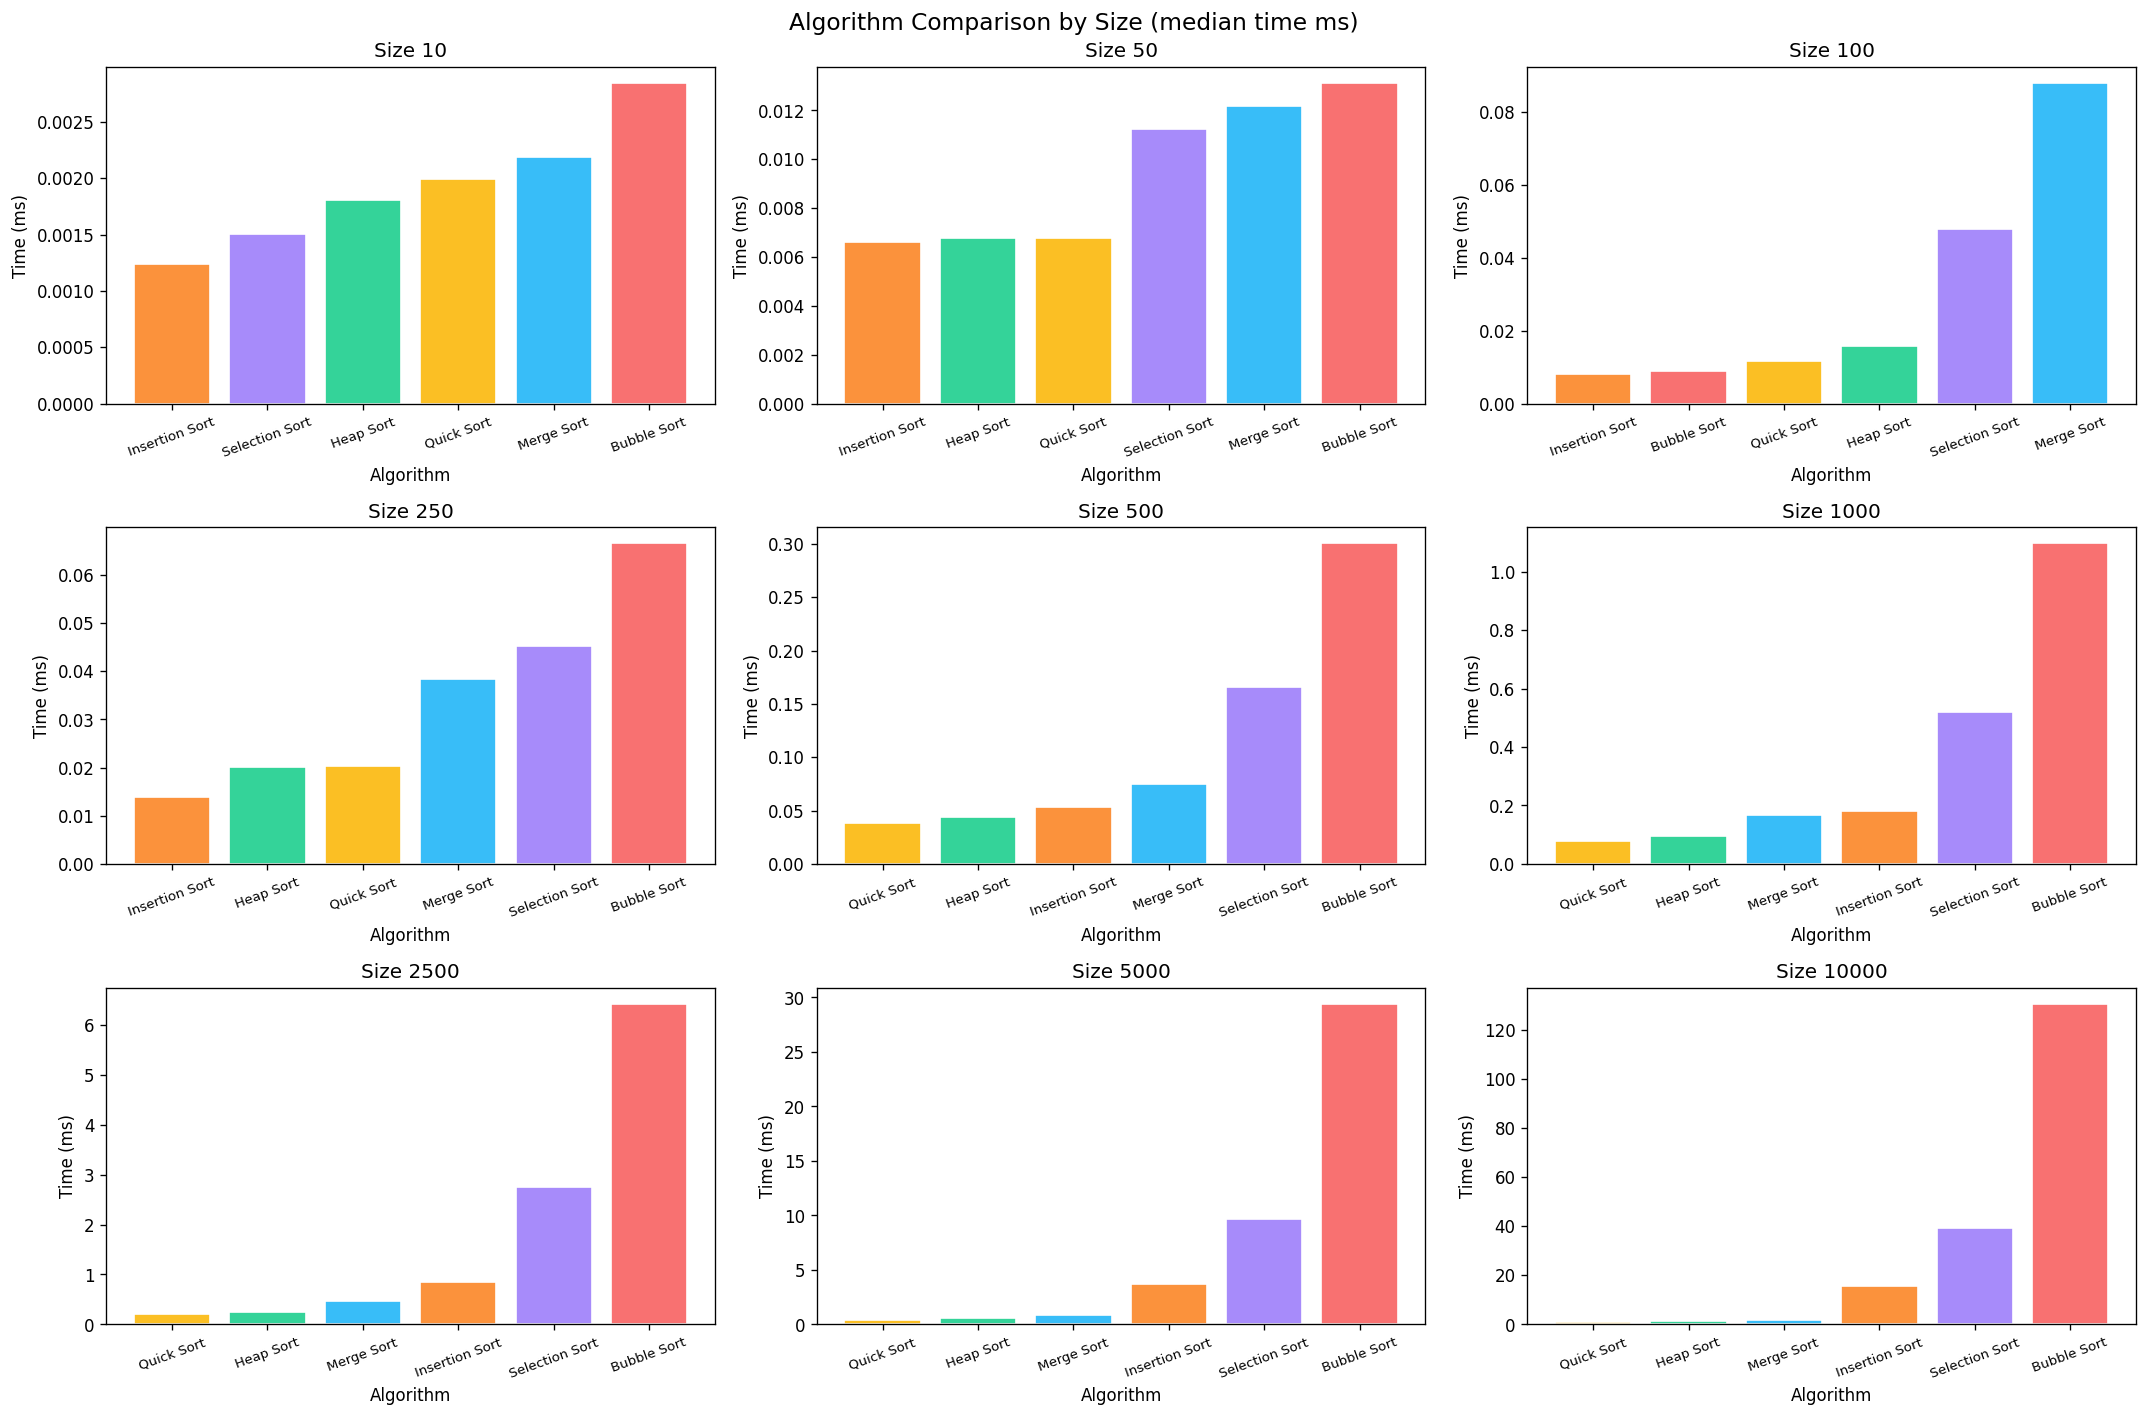

In [26]:
sizes = sorted(agg['size'].unique())
n = len(sizes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, size in enumerate(sizes):
    ax = axes[i]
    subset = (
        agg[agg['size'] == size]
        .groupby('algorithm')['avg_time']
        .median()
        .sort_values()
    )
    colors = [ALGO_COLORS.get(algo, '#9ca3af') for algo in subset.index]

    ax.bar(subset.index, subset.values, color=colors, edgecolor='white')
    ax.set_title(f'Size {size}')
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Time (ms)')
    ax.tick_params(axis='x', rotation=20, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Algorithm Comparison by Size (median time ms)', fontsize=14)
plt.tight_layout()
plt.show()

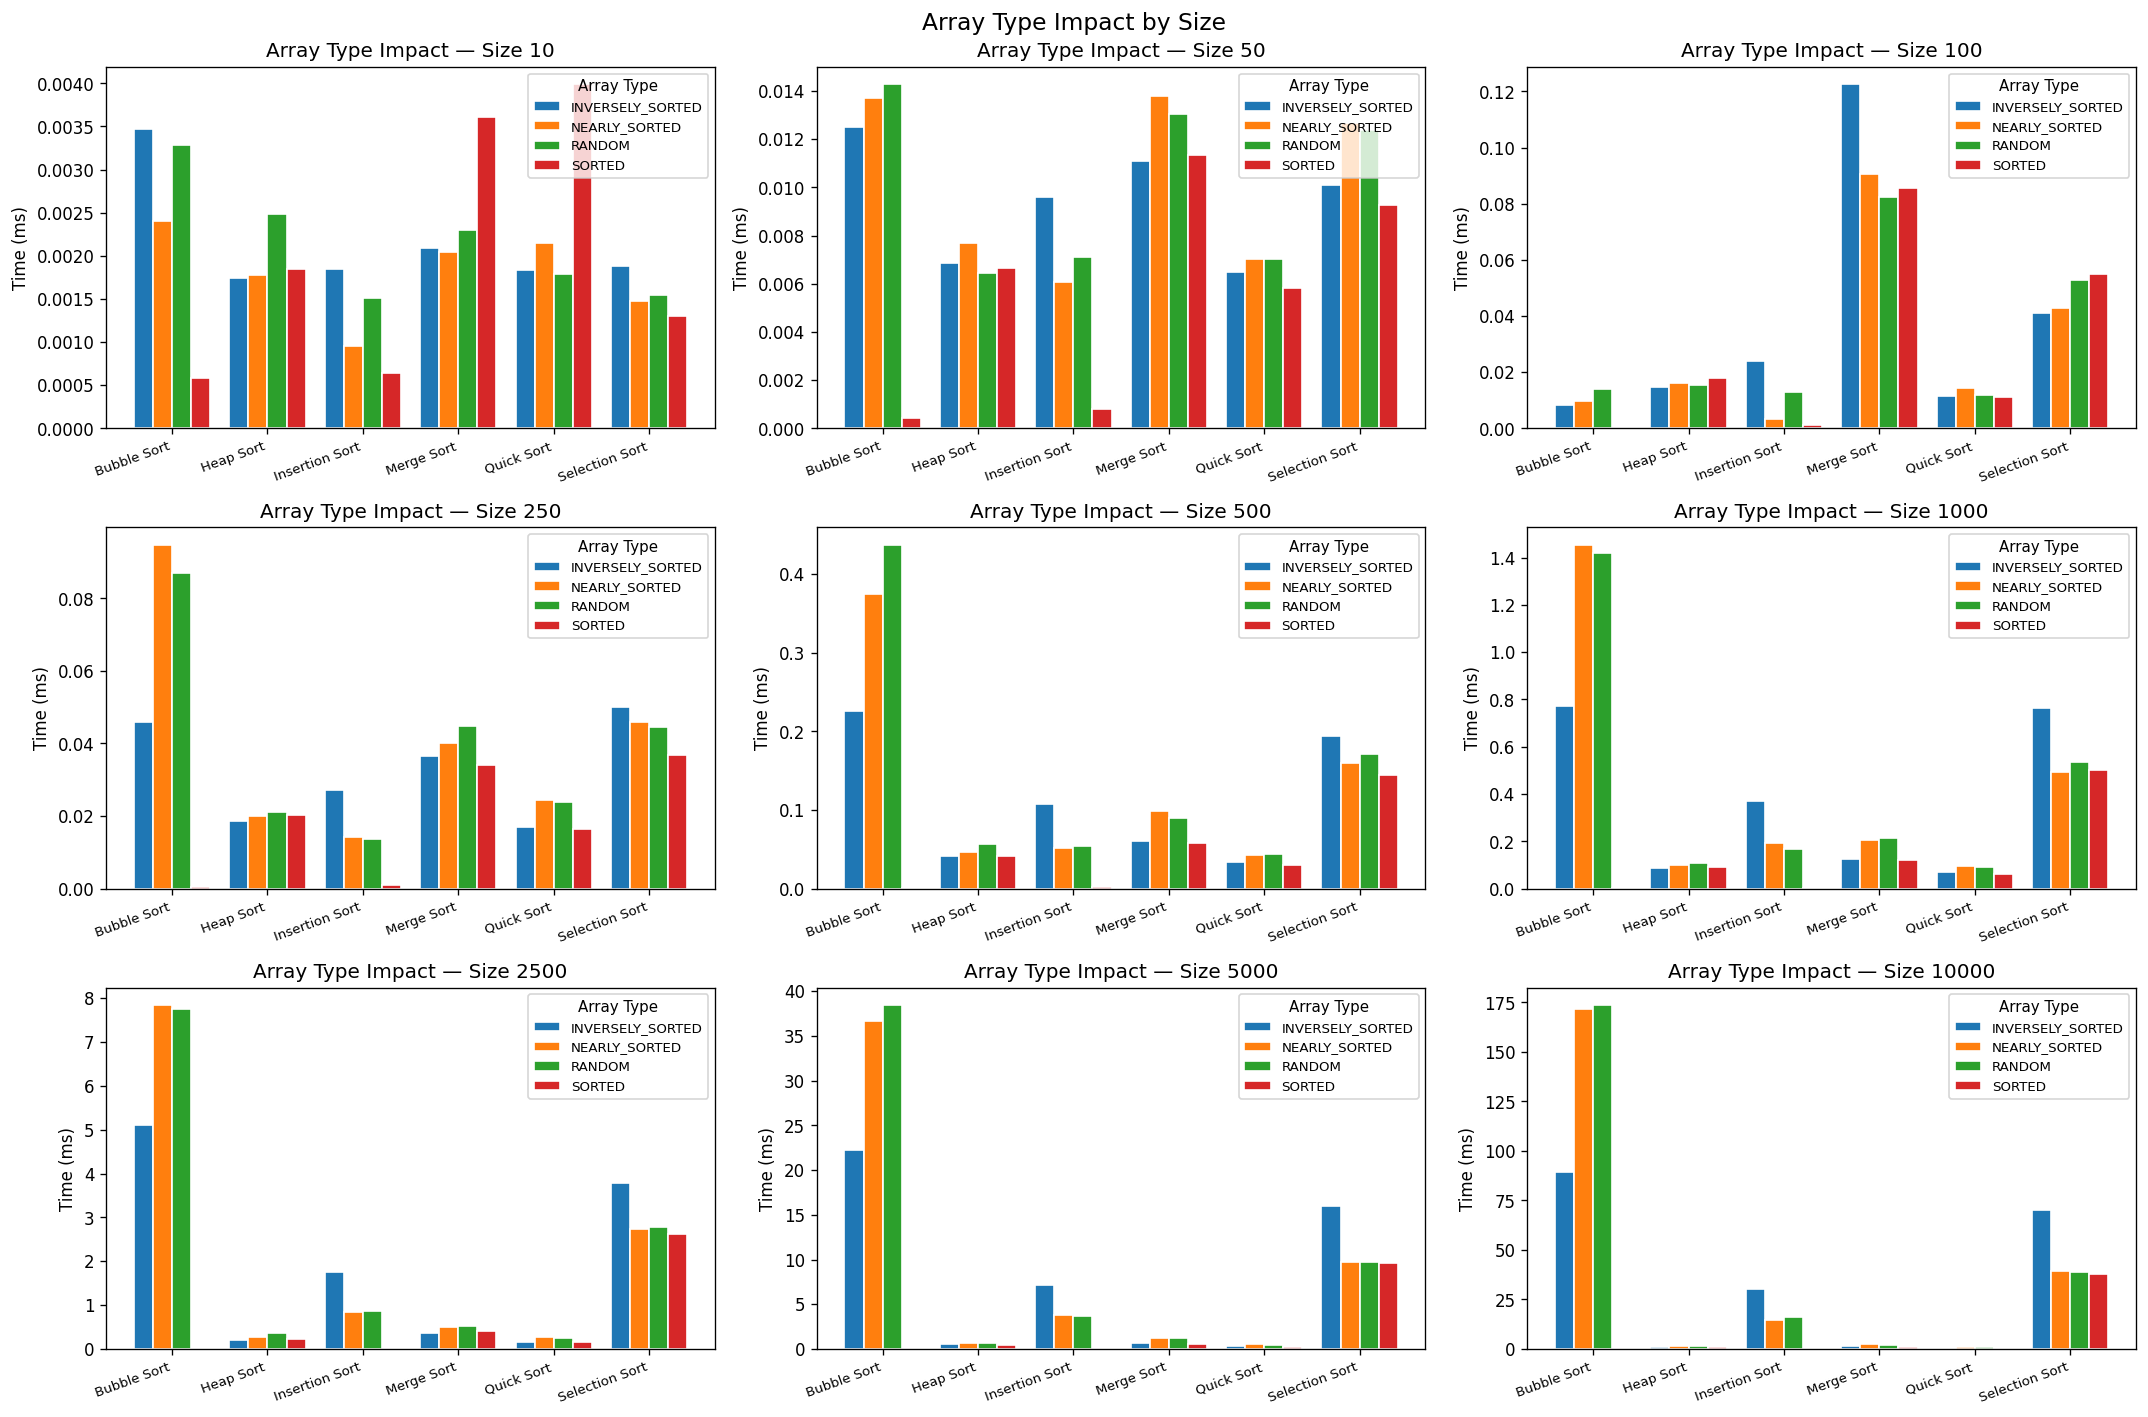

In [27]:
sizes = sorted(agg['size'].unique())
modes = sorted(agg['mode'].unique())
algorithms = sorted(agg['algorithm'].unique())

n = len(sizes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

x = np.arange(len(algorithms))
width = 0.8 / len(modes)

for i, size in enumerate(sizes):
    ax = axes[i]
    subset = agg[agg['size'] == size]

    for k, mode in enumerate(modes):
        vals = [
            subset[(subset['algorithm'] == algo) & (subset['mode'] == mode)]['avg_time'].median()
            for algo in algorithms
        ]
        ax.bar(x + (k - (len(modes) - 1) / 2) * width, vals, width, label=mode, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'Array Type Impact — Size {size}')
    ax.set_ylabel('Time (ms)')
    ax.legend(title='Array Type', fontsize=8, title_fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Array Type Impact by Size', fontsize=14)
plt.tight_layout()
plt.show()

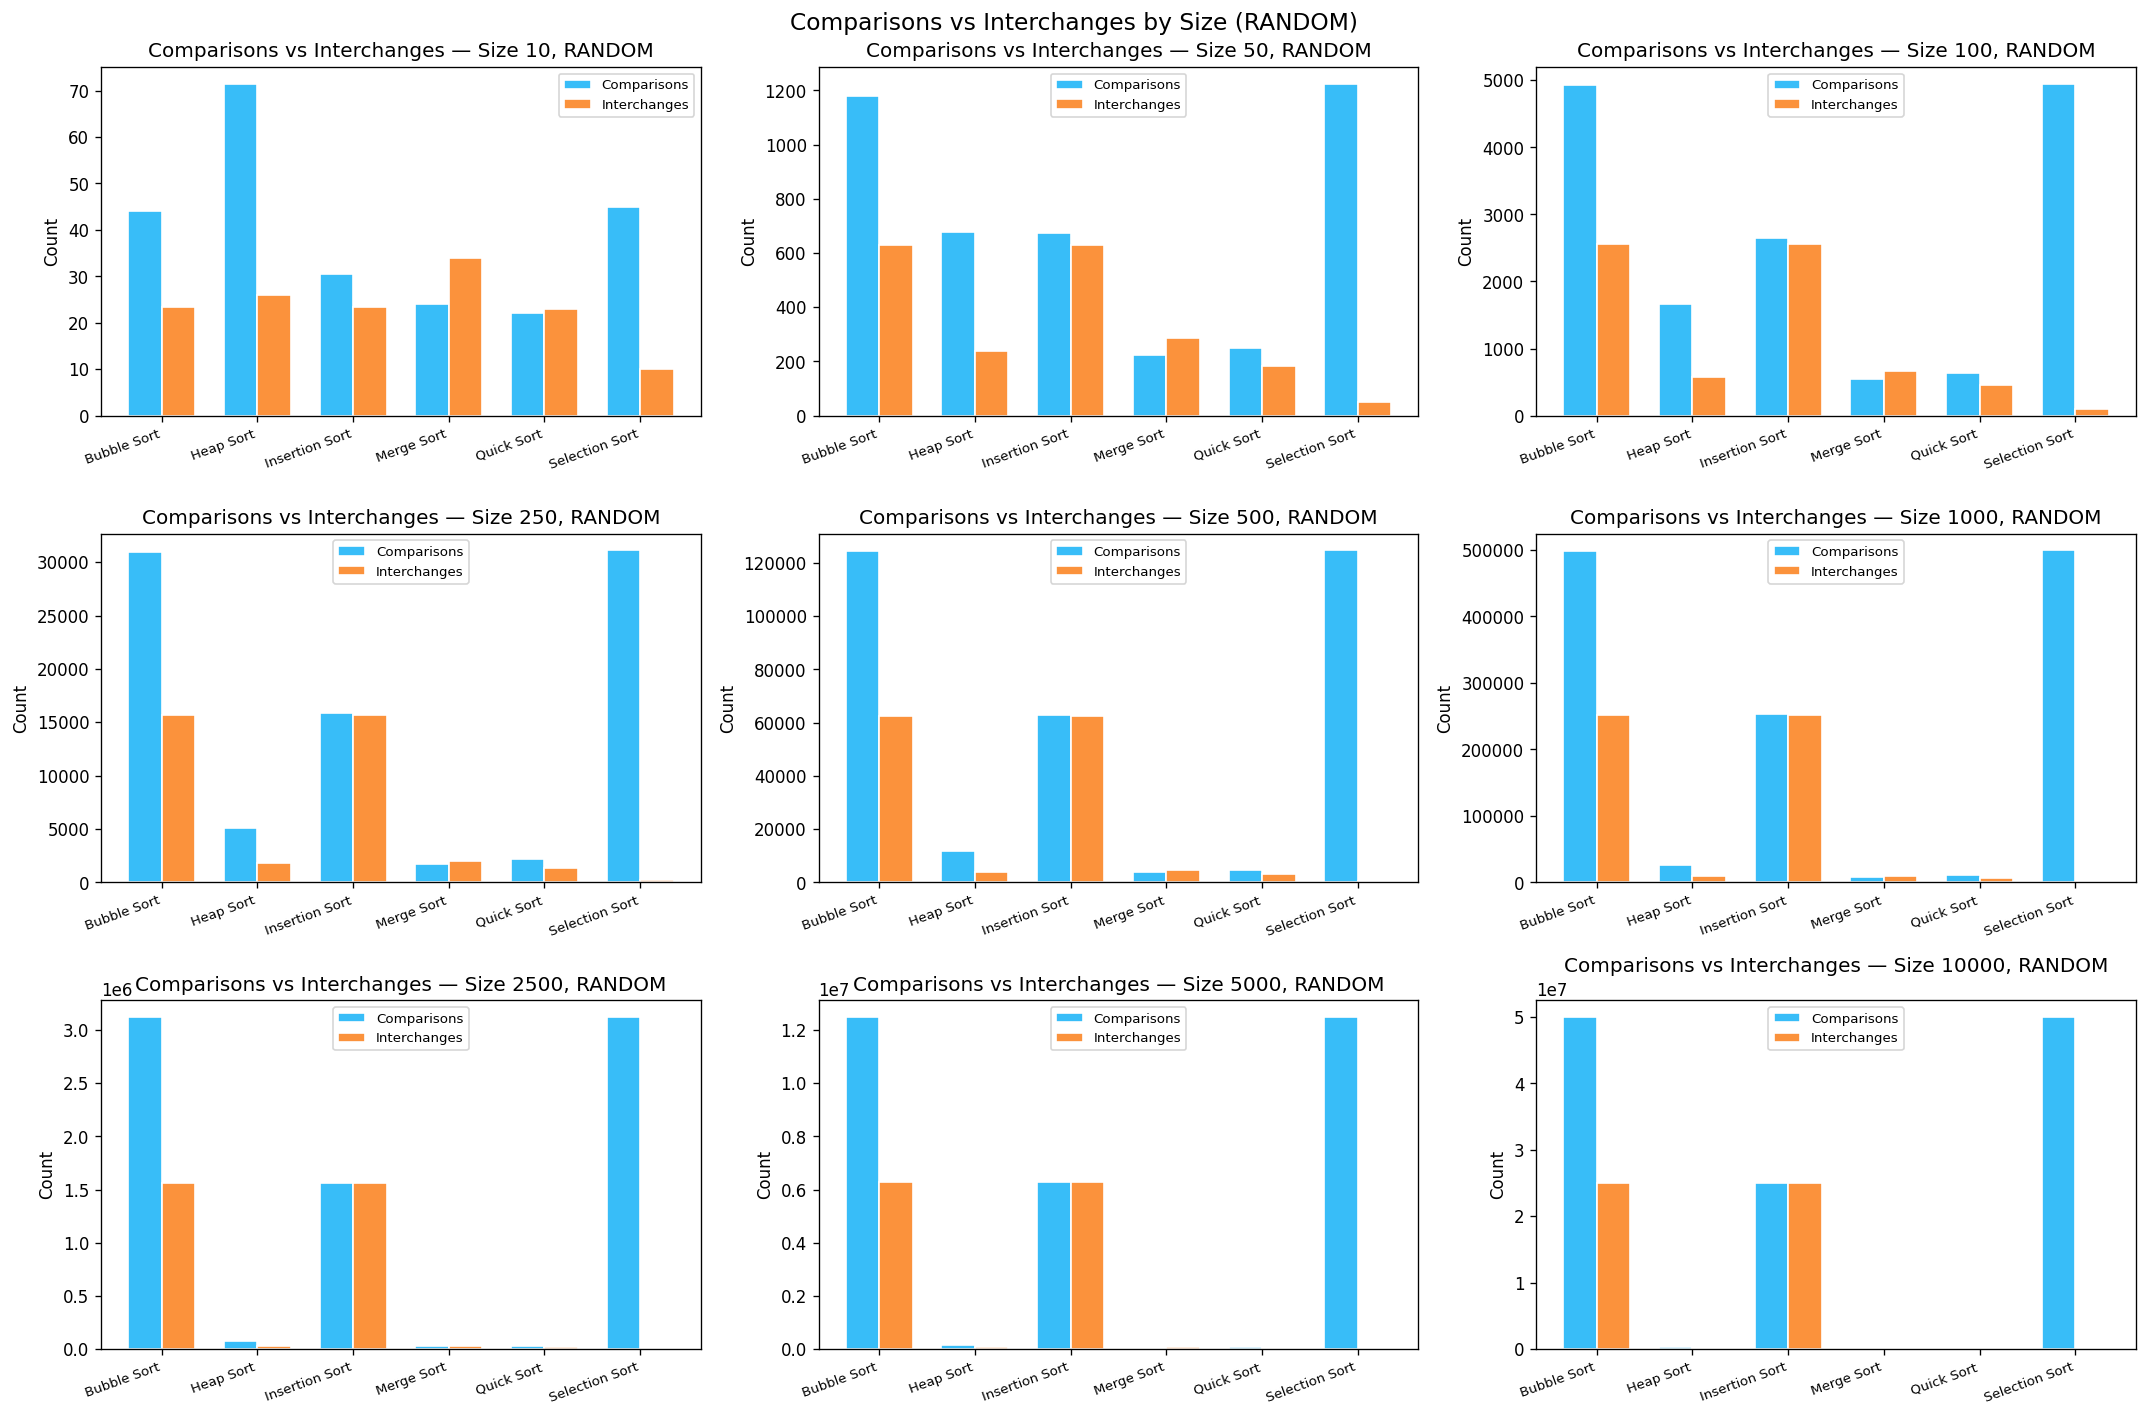

In [28]:
subset_random = agg[agg['mode'] == 'RANDOM']
sizes = sorted(subset_random['size'].unique())
algorithms = sorted(subset_random['algorithm'].unique())

n = len(sizes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, size in enumerate(sizes):
    ax = axes[i]
    subset = (
        subset_random[subset_random['size'] == size]
        .set_index('algorithm')
        .reindex(algorithms)
        .reset_index()
    )

    x = np.arange(len(subset))
    width = 0.35

    ax.bar(x - width / 2, subset['comparisons'], width, label='Comparisons', color='#38bdf8', edgecolor='white')
    ax.bar(x + width / 2, subset['interchanges'], width, label='Interchanges', color='#fb923c', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(subset['algorithm'], rotation=20, ha='right', fontsize=8)
    ax.set_title(f'Comparisons vs Interchanges — Size {size}, RANDOM')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Comparisons vs Interchanges by Size (RANDOM)', fontsize=14)
plt.tight_layout()
plt.show()

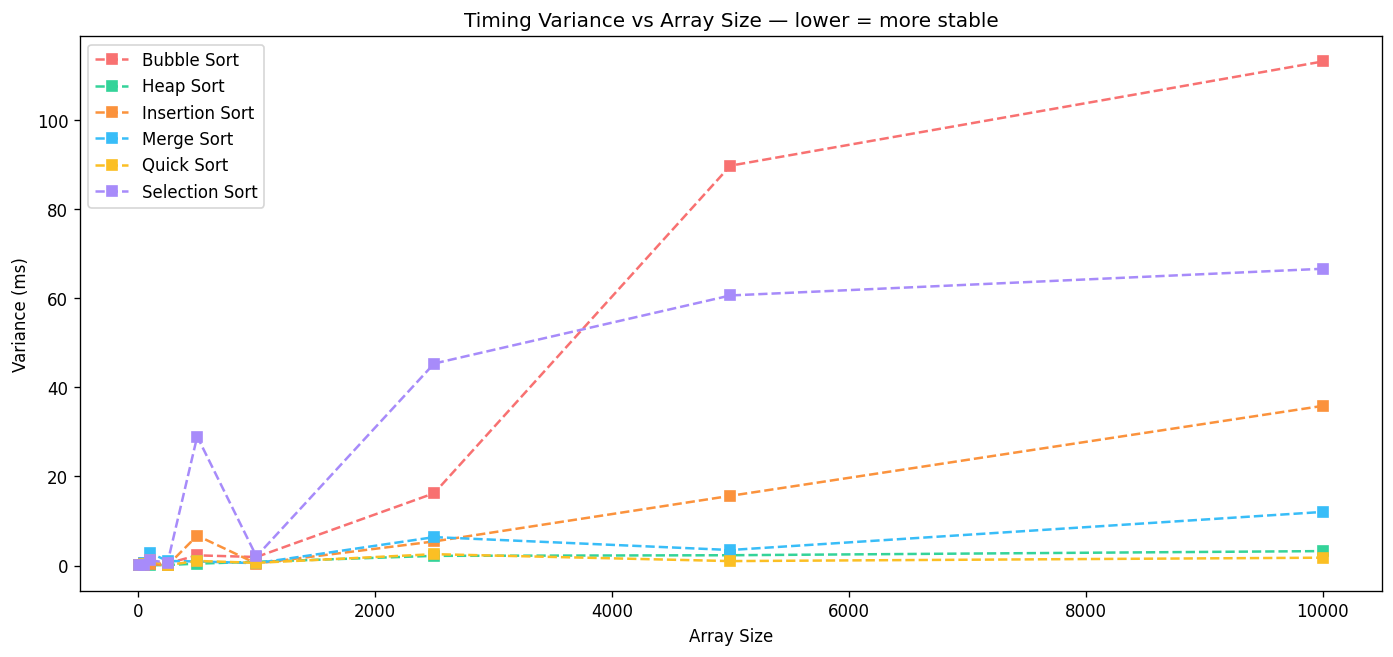

In [18]:
agg['variance'] = agg['max_time'] - agg['min_time']

stability = agg.groupby(['algorithm', 'size'])['variance'].median().reset_index()

for algo in stability['algorithm'].unique():
    subset = stability[stability['algorithm'] == algo]
    plt.plot(subset['size'], subset['variance'], marker='s', 
             label=algo, color=ALGO_COLORS.get(algo), linestyle='--')

plt.title('Timing Variance vs Array Size — lower = more stable')
plt.xlabel('Array Size')
plt.ylabel('Variance (ms)')
plt.legend()
plt.show()

In [19]:
winner = agg.loc[agg.groupby(['size', 'mode'])['avg_time'].idxmin()]
winner = winner[['size', 'mode', 'algorithm', 'avg_time']]

pivot = winner.pivot_table(index='size', columns='mode', values='algorithm', aggfunc='first')
print(pivot.to_string())

mode  INVERSELY_SORTED   NEARLY_SORTED          RANDOM       SORTED
size                                                               
10           Heap Sort  Insertion Sort  Insertion Sort  Bubble Sort
50          Quick Sort  Insertion Sort       Heap Sort  Bubble Sort
100        Bubble Sort  Insertion Sort      Quick Sort  Bubble Sort
250         Quick Sort  Insertion Sort  Insertion Sort  Bubble Sort
500         Quick Sort      Quick Sort      Quick Sort  Bubble Sort
1000        Quick Sort      Quick Sort      Quick Sort  Bubble Sort
2500        Quick Sort       Heap Sort      Quick Sort  Bubble Sort
5000        Quick Sort      Quick Sort      Quick Sort  Bubble Sort
10000       Quick Sort      Quick Sort      Quick Sort  Bubble Sort


In [24]:
def theoretical(n, complexity):
    if complexity == 'n2':
        return n ** 2
    if complexity == 'nlogn':
        return n * np.log2(n)
    if complexity == 'n':
        return n

ALGO_COMPLEXITY = {
    'Bubble Sort':    'n2',
    'Selection Sort': 'n2',
    'Insertion Sort': 'n2',
    'Merge Sort':     'nlogn',
    'Heap Sort':      'nlogn',
    'Quick Sort':     'nlogn',
}

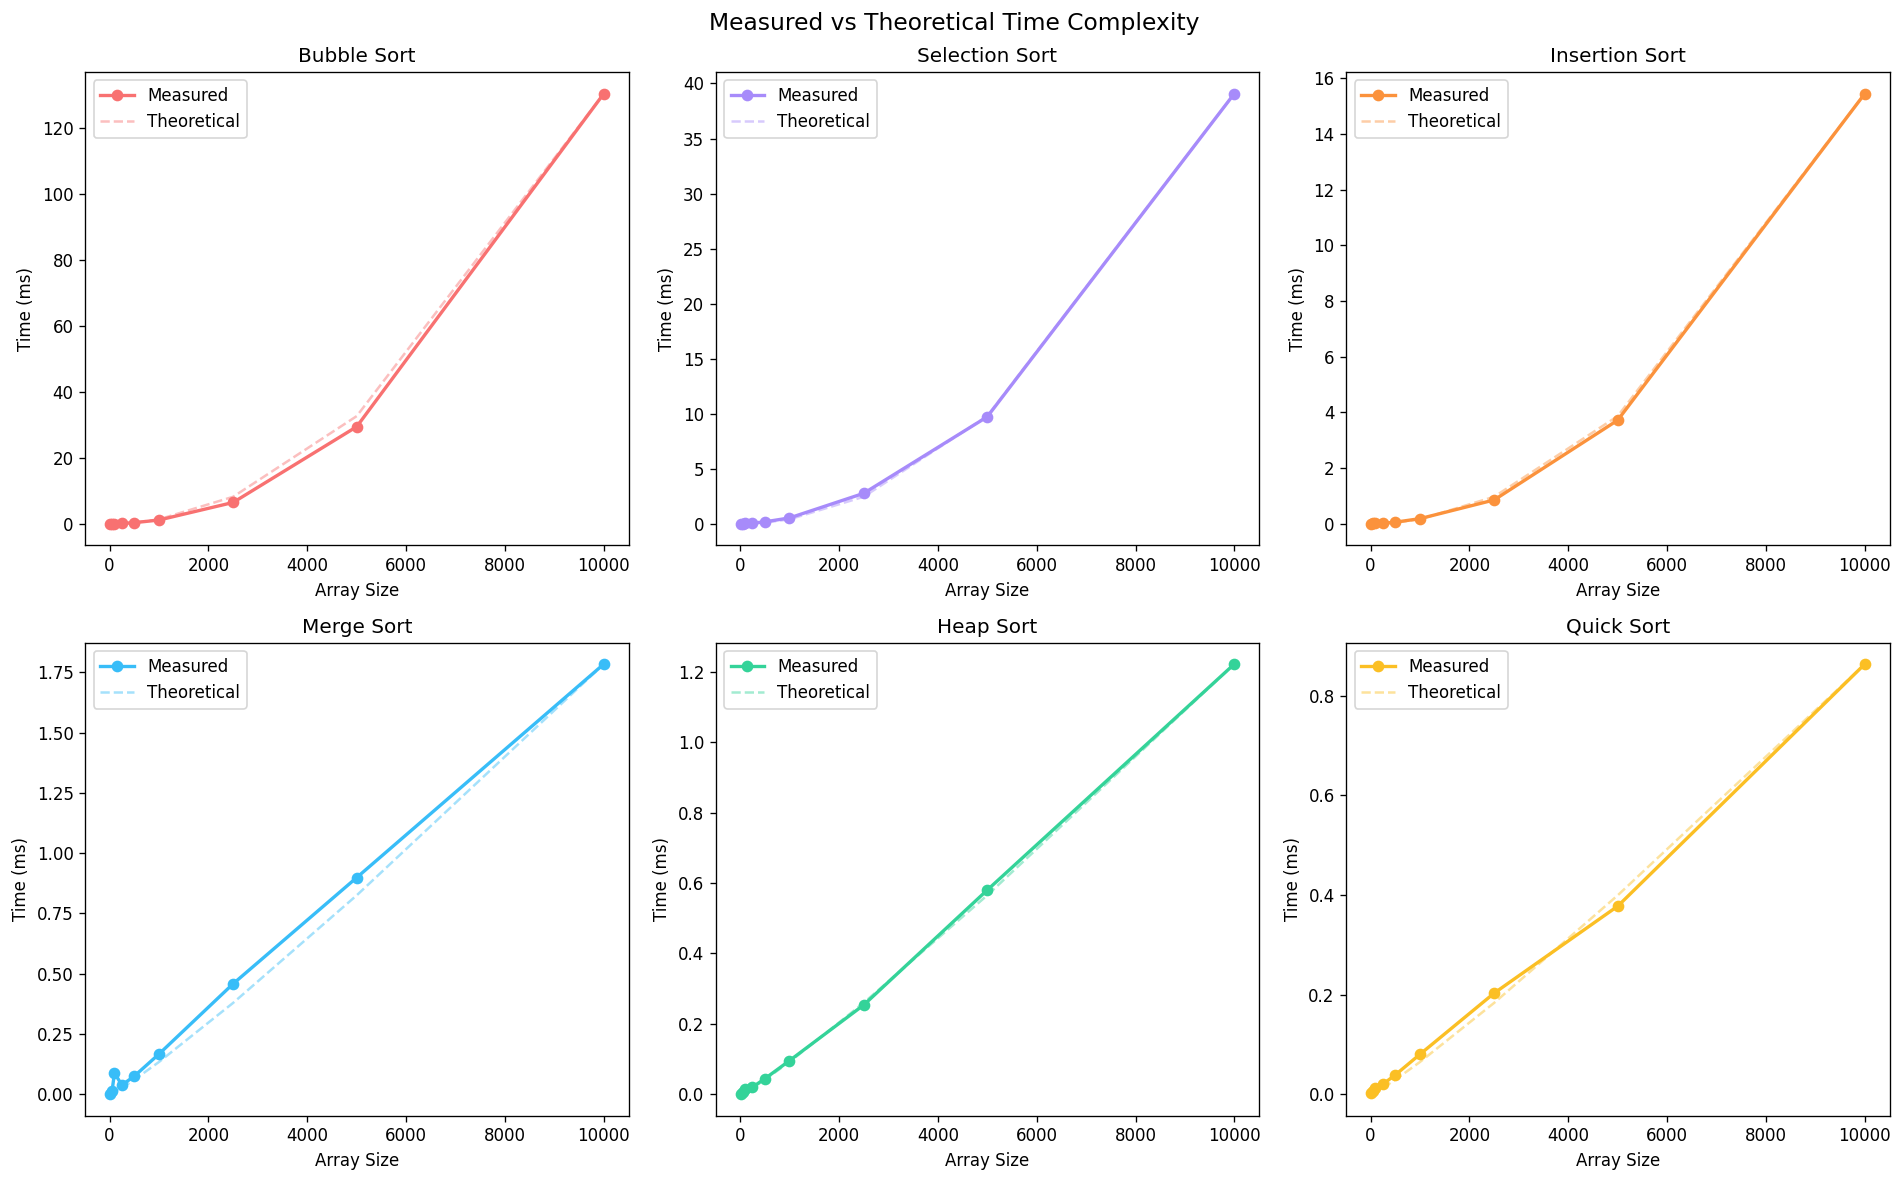

In [25]:
sizes = np.array(sorted(agg['size'].unique()))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (algo, complexity) in enumerate(ALGO_COMPLEXITY.items()):
    ax = axes[i]
    
    # actual measured time
    subset = agg[agg['algorithm'] == algo].groupby('size')['avg_time'].median()
    ax.plot(subset.index, subset.values, marker='o', 
            color=ALGO_COLORS[algo], label='Measured', linewidth=2)
    
    # theoretical curve — scale it to match the actual time range
    theory = np.array([theoretical(n, complexity) for n in sizes], dtype=float)
    theory = theory / theory.max() * subset.values.max()
    ax.plot(sizes, theory, linestyle='--', color=ALGO_COLORS[algo], alpha=0.45, label='Theoretical')
    
    ax.set_title(algo, fontsize=12)
    ax.set_xlabel('Array Size')
    ax.set_ylabel('Time (ms)')
    ax.legend()

plt.suptitle('Measured vs Theoretical Time Complexity', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
agg = df.groupby(["algorithm", "size", "mode"]).agg(
    sample_count=("avg_time", "count"),
    avg_time_median=("avg_time", "median"),
    avg_time_mean=("avg_time", "mean"),
    avg_time_std=("avg_time", "std"),
    avg_time_min=("avg_time", "min"),
    avg_time_max=("avg_time", "max"),
    avg_time_q25=("avg_time", lambda s: s.quantile(0.25)),
    avg_time_q75=("avg_time", lambda s: s.quantile(0.75)),
    avg_time_p95=("avg_time", lambda s: s.quantile(0.95)),
    comparisons_median=("comparisons", "median"),
    interchanges_median=("interchanges", "median"),
).reset_index()

agg["avg_time_iqr"] = agg["avg_time_q75"] - agg["avg_time_q25"]
agg["avg_time_cv"] = agg["avg_time_std"] / agg["avg_time_median"].replace(0, np.nan)
agg["ops_total_median"] = agg["comparisons_median"] + agg["interchanges_median"]

In [30]:
print(agg.shape)
agg.head()

(216, 17)


,algorithm,size,mode,sample_count,avg_time_median,avg_time_mean,avg_time_std,avg_time_min,avg_time_max,avg_time_q25,avg_time_q75,avg_time_p95,comparisons_median,interchanges_median,avg_time_iqr,avg_time_cv,ops_total_median
0,Bubble Sort,10,INVERSELY_SORTED,10,0.003465,0.002959,0.001830,0.00049,0.00607,0.001280,0.003792,0.005224,45.0,45.0,0.002512,0.528228,90.0
1,Bubble Sort,10,NEARLY_SORTED,10,0.002400,0.002074,0.001105,0.00049,0.00330,0.001070,0.002877,0.003295,42.0,20.0,0.001807,0.460551,62.0
2,Bubble Sort,10,RANDOM,10,0.003290,0.002591,0.001352,0.00041,0.00387,0.001445,0.003488,0.003717,44.0,23.5,0.002043,0.410944,67.5
3,Bubble Sort,10,SORTED,10,0.000580,0.000636,0.000447,0.00018,0.00162,0.000295,0.000692,0.001390,9.0,0.0,0.000397,0.769909,9.0
4,Bubble Sort,50,INVERSELY_SORTED,10,0.012520,0.150420,0.419043,0.00963,1.34214,0.010890,0.016962,0.766747,1225.0,1225.0,0.006072,33.469911,2450.0


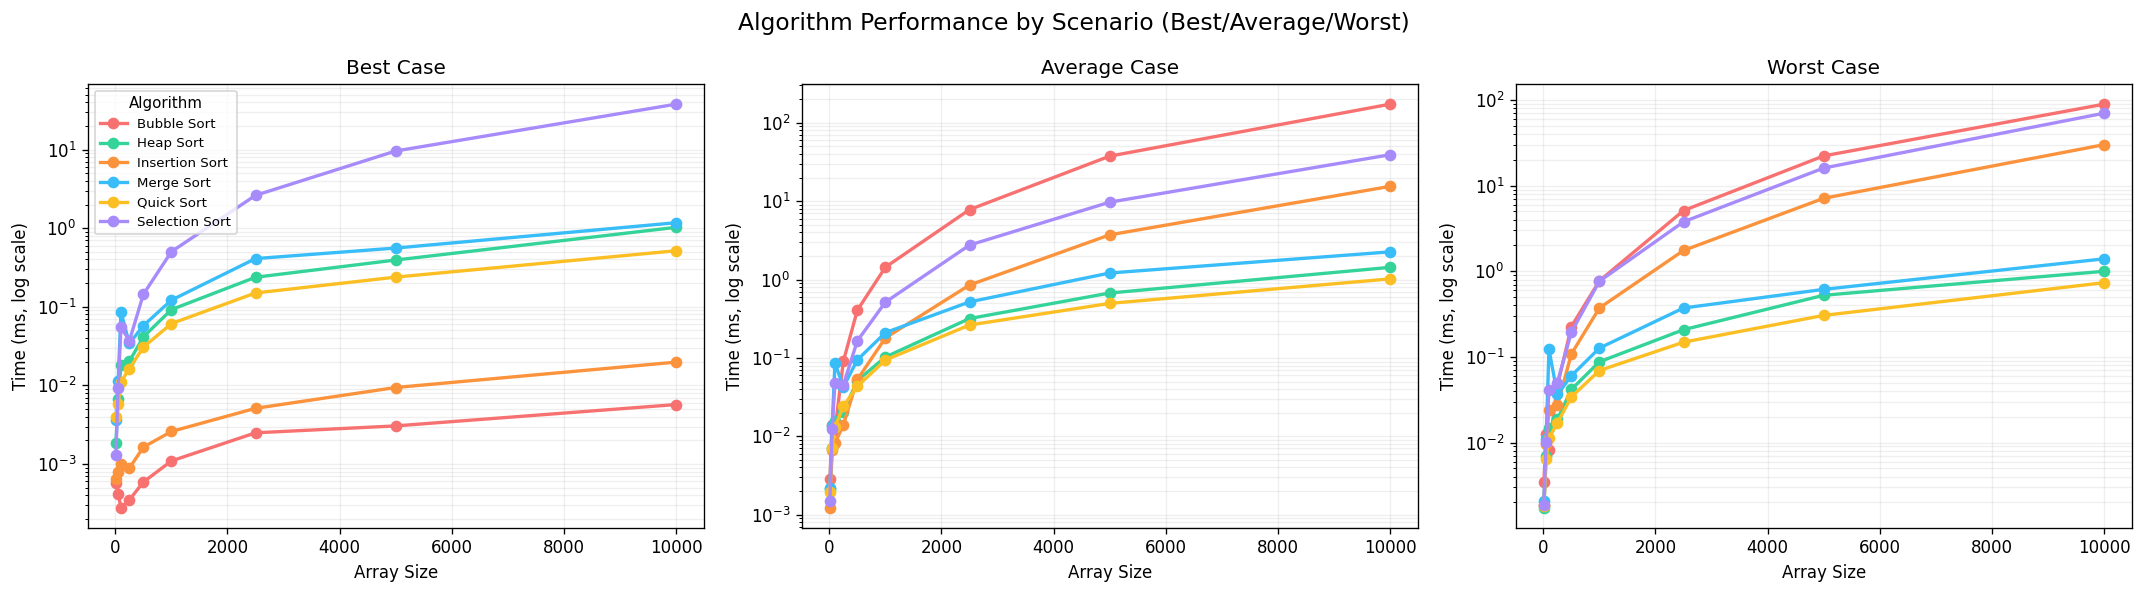

In [33]:
# Map dataset modes to complexity scenarios
mode_norm = agg['mode'].astype(str).str.upper().str.strip()
case_map = {
    'SORTED': 'Best Case',
    'INVERSELY_SORTED': 'Worst Case',
    'RANDOM': 'Average Case',
    'NEARLY_SORTED': 'Average Case',
}

case_df = agg.copy()
case_df['scenario'] = mode_norm.map(case_map)
case_df = case_df.dropna(subset=['scenario']).copy()

# Use the most detailed timing metric if available
time_col = 'avg_time_median' if 'avg_time_median' in case_df.columns else 'avg_time'

# Merge RANDOM + NEARLY_SORTED into one average case value
case_view = (
    case_df.groupby(['algorithm', 'size', 'scenario'])[time_col]
    .median()
    .reset_index()
    .sort_values(['scenario', 'algorithm', 'size'])
)

plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
scenario_order = ['Best Case', 'Average Case', 'Worst Case']

for i, scenario in enumerate(scenario_order):
    ax = axes[i]
    subset = case_view[case_view['scenario'] == scenario]

    for algo in sorted(subset['algorithm'].unique()):
        algo_data = subset[subset['algorithm'] == algo]
        y = algo_data[time_col].replace(0, np.nan)
        ax.plot(
            algo_data['size'],
            y,
            marker='o',
            linewidth=2,
            label=algo,
            color=ALGO_COLORS.get(algo)
        )

    if (subset[time_col] > 0).any():
        ax.set_yscale('log')

    ax.set_title(scenario)
    ax.set_xlabel('Array Size')
    ax.set_ylabel('Time (ms, log scale)')
    ax.grid(alpha=0.2, which='both')

axes[0].legend(title='Algorithm', fontsize=8, title_fontsize=9)
plt.suptitle('Algorithm Performance by Scenario (Best/Average/Worst)', fontsize=14)
plt.tight_layout()
plt.show()